###Model Evaluation

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Project Root
PROJECT_ROOT = Path("..")

# Dataset Paths
TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "train"
VAL_PATH = PROJECT_ROOT / "data" / "processed" / "validation"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "test"

# Model Path
MODEL_PATH = PROJECT_ROOT / "models" / "best_model.keras"

# Report Path
REPORT_PATH = PROJECT_ROOT / "reports" / "evaluation"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [3]:
model = load_model(MODEL_PATH)

print("Trained model loaded successfully!")

Trained model loaded successfully!


In [5]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test dataset loaded successfully!")
print("Classes:", len(test_dataset.class_names))

Found 5459 files belonging to 38 classes.
Test dataset loaded successfully!
Classes: 38


In [7]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Model Evaluation on Test Dataset")

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

171/171 ━━━━━━━━━━━━━━━━━━━━ 127s 741ms/step - accuracy: 0.9820 - loss: 0.0549
Model Evaluation on Test Dataset
Test Accuracy : 0.9820
Test Loss     : 0.0549


In [8]:
history_df = pd.read_csv(REPORT_PATH / "training_history.csv")

history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.917958,0.248756,0.966587,0.116326
1,0.937438,0.183584,0.971756,0.094021
2,0.944876,0.160415,0.973232,0.085071
3,0.949412,0.149676,0.978401,0.070741
4,0.953027,0.136989,0.977294,0.072812


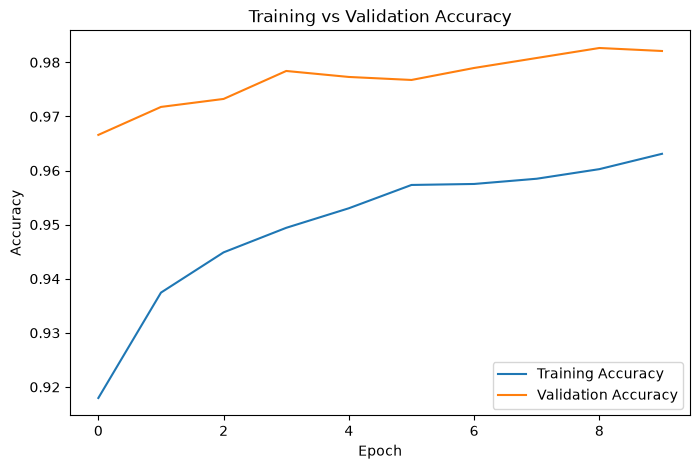

In [9]:
# Plot Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

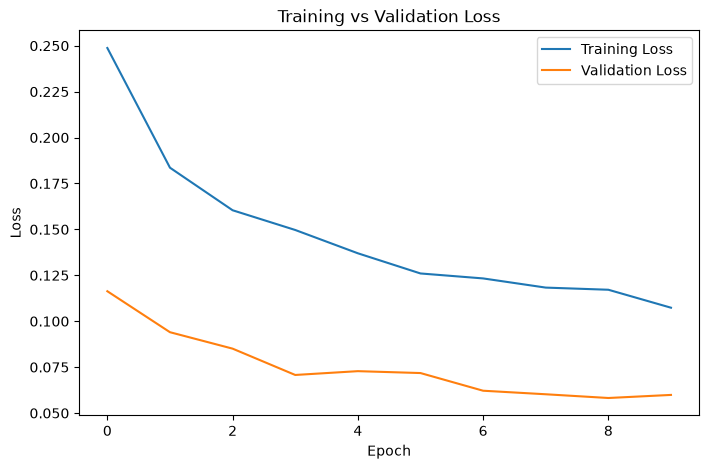

In [10]:
# Plot Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

171/171 ━━━━━━━━━━━━━━━━━━━━ 151s 871ms/step


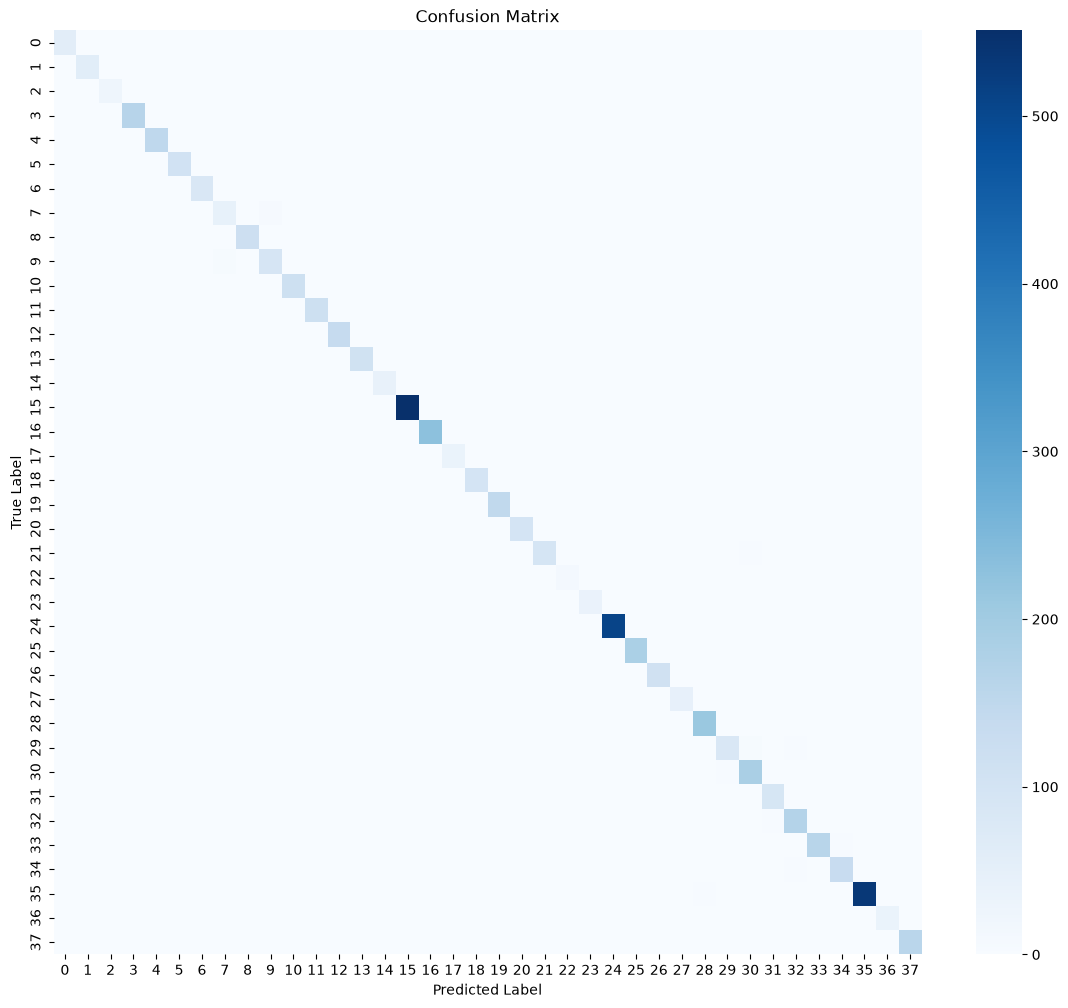

In [11]:
# Generate True Labels
y_true = np.concatenate([labels.numpy() for _, labels in test_dataset])

# Predict Labels
predictions = model.predict(test_dataset, verbose=1)
y_pred = np.argmax(predictions, axis=1)

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [12]:
# Get Class Names
class_names = test_dataset.class_names

# Generate Report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Display Report
report_df

,precision,recall,f1-score,support
Apple___Apple_scab,1.000000,0.952381,0.975610,63.000000
Apple___Black_rot,0.984127,0.984127,0.984127,63.000000
Apple___Cedar_apple_rust,1.000000,0.964286,0.981818,28.000000
Apple___healthy,0.976331,1.000000,0.988024,165.000000
Blueberry___healthy,1.000000,0.993377,0.996678,151.000000
Cherry___Powdery_mildew,0.990654,1.000000,0.995305,106.000000
Cherry___healthy,0.988506,1.000000,0.994220,86.000000
Corn___Cercospora_leaf_spot Gray_leaf_spot,0.900000,0.865385,0.882353,52.000000
Corn___Common_rust,0.991736,1.000000,0.995851,120.000000
Corn___Northern_Leaf_Blight,0.930000,0.939394,0.934673,99.000000


In [14]:
# Save Classification Report

report_df.to_csv(
    REPORT_PATH / "classification_report.csv",
    index=True
)

print("Classification report saved successfully!")

Classification report saved successfully!


In [15]:
# Create Evaluation Summary

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Test Loss"
    ],
    "Value": [
        test_accuracy,
        test_loss
    ]
})

evaluation_summary.to_csv(
    REPORT_PATH / "evaluation_summary.csv",
    index=False
)

print(evaluation_summary)
print("\nEvaluation summary saved successfully!")

          Metric     Value
0  Test Accuracy  0.982048
1      Test Loss  0.054891

Evaluation summary saved successfully!
